In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import cross_val_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

print('Imports OK')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

Imports OK
pandas 3.0.1 | numpy 2.4.2


In [2]:
df = pd.read_excel('Base_ER_FR.xlsx')

print(f'Dimensions initiales : {df.shape}')
print(f'\nVariables : {list(df.columns)}')
print(f'\nAperçu :')
df.head(3)

Dimensions initiales : (100000, 20)

Variables : ['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET', 'E_EAD', 'E_OFF', 'E_ONB', 'MREVAU', 'MREVNU', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'Unnamed: 19']

Aperçu :


,ID,AGE_CLI,B_MAT,B_RESMAT,CLASSACT,CSP,DARRET,E_EAD,E_OFF,E_ONB,MREVAU,MREVNU,MREVTOT,MTECH,NBIMP,NB_ECH,produit,RA,Tx,Unnamed: 19
0,a000001,53.0,NaN,NaN,1,42.0,201901,NaN,NaN,NaN,0.0,3216.0,3216.0,289.18,0,60,AMO,1302.91,2.309425,NaN
1,a000002,52.0,NaN,NaN,1,52.0,201901,NaN,NaN,NaN,0.0,2600.0,2600.0,340.98,0,60,AMO,4483.04,1.928135,NaN
2,a000003,53.0,NaN,NaN,1,45.0,201901,NaN,NaN,NaN,0.0,11000.0,11000.0,315.32,0,60,AMO,2468.04,2.377371,NaN


In [3]:
print('Types de variables :')
print(df.dtypes)
print(f'\nValeurs manquantes par variable :')
print(df.isna().sum().sort_values(ascending=False))

Types de variables :
ID                 str
AGE_CLI        float64
B_MAT          float64
B_RESMAT       float64
CLASSACT         int64
CSP            float64
DARRET           int64
E_EAD          float64
E_OFF          float64
E_ONB          float64
MREVAU         float64
MREVNU         float64
MREVTOT        float64
MTECH          float64
NBIMP            int64
NB_ECH           int64
produit            str
RA             float64
Tx             float64
Unnamed: 19    float64
dtype: object

Valeurs manquantes par variable :
Unnamed: 19    100000
Tx               4886
CSP              2478
B_RESMAT         1380
E_ONB            1380
E_OFF            1380
B_MAT            1380
E_EAD            1380
AGE_CLI           476
MREVTOT            46
MREVAU             46
MREVNU             46
ID                  0
DARRET              0
CLASSACT            0
MTECH               0
NB_ECH              0
NBIMP               0
RA                  0
produit             0
dtype: int64


In [4]:
n0 = len(df)
log_nettoyage = [('Initial', n0)]
print(f'[0] Initial : {n0:,} observations')

# ── B_MAT : filtrage des maturités aberrantes
# Seuil à 170 mois : supprime les valeurs dans la queue sparse (cf. analyse StatDes)
# On garde les NaN pour ne pas les perdre ici (traitement ultérieur)
df = df[(df['B_MAT'] <= 170) | (df['B_MAT'].isna())]
n1 = len(df)
log_nettoyage.append(('B_MAT <= 170 ou NaN', n1))
print(f'[1] Après filtre B_MAT <= 170 (NaN conservés) : {n1:,} (-{n0-n1:,})')

# ── DARRET : conversion en datetime
# Format source : entier YYYYMM (ex: 201901 = janvier 2019)
df['DARRET'] = pd.to_datetime(
    df['DARRET'].astype(str),
    format='%Y%m',
    errors='coerce'
)
n_darret_invalid = df['DARRET'].isna().sum()
print(f'    DARRET : {n_darret_invalid} valeurs non convertibles (ignorées dans l analyse temporelle)')

# ── Drop variables dégénérées ou parfaitement colinéaires
# E_OFF   : toutes valeurs = 0 (aucune variation)
# MREVAU  : composante de MREVTOT → colinéarité parfaite si MREVTOT conservé
# MREVNU  : idem
# Unnamed : artefact Excel
cols_to_drop = [c for c in ['Unnamed: 19', 'E_OFF', 'MREVAU', 'MREVNU'] if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f'[2] Colonnes supprimées : {cols_to_drop}')

# ── E_ONB : parfaitement identique à E_EAD (colinéarité parfaite)
# Vérification avant suppression
if 'E_ONB' in df.columns:
    egal = (df['E_ONB'] == df['E_EAD']).mean()
    print(f'    E_ONB == E_EAD : {egal:.1%} des observations → suppression de E_ONB')
    df = df.drop(columns=['E_ONB'])

# ── Produit : restriction aux contrats amortissables (AMO)
# AR (1.63% des contrats) : structure bullet → traitement séparé hors périmètre
df = df[df['produit'] != 'AR']
n2 = len(df)
log_nettoyage.append(('produit == AMO', n2))
print(f'[3] Après filtre produit=AMO : {n2:,} (-{n1-n2:,})')

# ── RA : suppression des valeurs négatives (incohérentes économiquement)
df = df[df['RA'] >= 0]
n3 = len(df)
log_nettoyage.append(('RA >= 0', n3))
print(f'[4] Après filtre RA >= 0 : {n3:,} (-{n2-n3:,})')

# ── Tx : taux d'intérêt
# Valeurs négatives : économiquement impossibles sur crédit conso
# Valeurs < 0.5% : probables erreurs de saisie ou produits hors périmètre
df = df[df['Tx'] >= 0.5]
n4 = len(df)
log_nettoyage.append(('Tx >= 0.5%', n4))
print(f'[5] Après filtre Tx >= 0.5% : {n4:,} (-{n3-n4:,})')

print(f'\n→ Après nettoyage : {n4:,} observations ({n4/n0:.1%} de la base initiale)')

[0] Initial : 100,000 observations
[1] Après filtre B_MAT <= 170 (NaN conservés) : 96,179 (-3,821)
    DARRET : 0 valeurs non convertibles (ignorées dans l analyse temporelle)
[2] Colonnes supprimées : ['Unnamed: 19', 'E_OFF', 'MREVAU', 'MREVNU']
    E_ONB == E_EAD : 98.6% des observations → suppression de E_ONB
[3] Après filtre produit=AMO : 94,615 (-1,564)
[4] Après filtre RA >= 0 : 94,269 (-346)
[5] Après filtre Tx >= 0.5% : 88,490 (-5,779)

→ Après nettoyage : 88,490 observations (88.5% de la base initiale)


In [5]:
n_avant_na = len(df)

# ── AGE_CLI : imputation par la médiane + indicateur de manquance
# Indicateur capture l'effet potentiel de l'absence d'information sur l'âge
df['AGE_MISSING'] = df['AGE_CLI'].isna().astype(int)
mediane_age = df['AGE_CLI'].median()
df['AGE_CLI'] = df['AGE_CLI'].fillna(mediane_age)
print(f'AGE_CLI : {df["AGE_MISSING"].sum()} imputés par médiane ({mediane_age:.0f} ans)')

# ── CSP : catégorie "Inconnu" pour les manquants
# Préserve l'information que la donnée est manquante (peut être prédictif)
n_csp_missing = df['CSP'].isna().sum()
df['CSP'] = df['CSP'].fillna('Inconnu')
print(f'CSP : {n_csp_missing} modalités "Inconnu" créées')

# ── Variables structurelles : suppression si manquantes
# B_MAT, B_RESMAT, E_EAD : ESSENTIELLES pour le calcul de l AGE_CONTRAT
# et la définition de l événement. Non reconstructibles → suppression.
n_avant_struct = len(df)
df = df.dropna(subset=['B_MAT', 'B_RESMAT', 'E_EAD'])
print(f'B_MAT / B_RESMAT / E_EAD : {n_avant_struct - len(df)} lignes supprimées (manquants structurels)')

# ── MREVTOT : imputation par la médiane
mediane_rev = df['MREVTOT'].median()
n_rev_missing = df['MREVTOT'].isna().sum()
df['MREVTOT'] = df['MREVTOT'].fillna(mediane_rev)
print(f'MREVTOT : {n_rev_missing} imputés par médiane ({mediane_rev:.0f} €)')

n_apres_na = len(df)
print(f'\n→ Après traitement des NaN : {n_apres_na:,} observations')

# Vérification finale : aucun NaN résiduel sur les variables utilisées
vars_check = ['B_MAT', 'B_RESMAT', 'E_EAD', 'AGE_CLI', 'MREVTOT', 'Tx', 'RA', 'NBIMP', 'MTECH']
nan_residuels = df[vars_check].isna().sum()
print(f'\nNaN résiduels sur variables clés :')
print(nan_residuels[nan_residuels > 0] if nan_residuels.sum() > 0 else '  → Aucun NaN résiduel ✓')

AGE_CLI : 458 imputés par médiane (52 ans)
CSP : 117 modalités "Inconnu" créées
B_MAT / B_RESMAT / E_EAD : 1302 lignes supprimées (manquants structurels)
MREVTOT : 42 imputés par médiane (2106 €)

→ Après traitement des NaN : 87,188 observations

NaN résiduels sur variables clés :
  → Aucun NaN résiduel ✓


In [6]:
# Journal de nettoyage récapitulatif
df_log = pd.DataFrame(log_nettoyage, columns=['Étape', 'N obs'])
df_log['Perte cum.'] = df_log['N obs'].apply(lambda x: f"{(1-x/n0):.1%}")
print('\n=== JOURNAL DE NETTOYAGE ===')
print(df_log.to_string(index=False))
print(f'\nBase finale : {len(df):,} observations ({len(df)/n0:.1%} de la base initiale)')


=== JOURNAL DE NETTOYAGE ===
              Étape  N obs Perte cum.
            Initial 100000       0.0%
B_MAT <= 170 ou NaN  96179       3.8%
     produit == AMO  94615       5.4%
            RA >= 0  94269       5.7%
         Tx >= 0.5%  88490      11.5%

Base finale : 87,188 observations (87.2% de la base initiale)


bench : probablement à modif:

In [7]:
csp_mapping = {
    21: 'Cadres', 22: 'Cadres', 23: 'Cadres',
    31: 'Prof_interm', 32: 'Prof_interm', 34: 'Prof_interm',
    35: 'Prof_interm', 36: 'Prof_interm', 37: 'Prof_interm',
    42: 'Employes', 43: 'Employes', 45: 'Employes',
    46: 'Employes', 47: 'Employes', 48: 'Employes',
    52: 'Ouvriers', 53: 'Ouvriers', 54: 'Ouvriers',
    55: 'Ouvriers', 56: 'Ouvriers',
    60: 'Retraites', 62: 'Retraites', 64: 'Retraites',
    65: 'Retraites', 69: 'Retraites', 70: 'Retraites',
}

# Application du mapping
df["csp"] = df["CSP"].map(csp_mapping)

csp_stats = pd.concat(
    [
        df["csp"].value_counts(),
        df["csp"].value_counts(normalize=True)
    ],
    axis=1
)

csp_stats.columns = ["effectif", "proportion"]
csp_stats



,effectif,proportion
csp,,
Retraites,35629,0.420813
Ouvriers,23908,0.282377
Employes,16811,0.198554
Prof_interm,6218,0.073441
Cadres,2101,0.024815


Construction variables

In [8]:
#AGE CONTRAT
df['AGE_CONTRAT'] = df['B_MAT'] - df['B_RESMAT']

# Diagnostic avant nettoyage
n_negatifs = (df['AGE_CONTRAT'] < 0).sum()
print(f"Contrats avec AGE_CONTRAT < 0 (B_RESMAT > B_MAT) : {n_negatifs} ({n_negatifs/len(df):.2%})")
print(f"Aperçu des cas problématiques :")
print(df.loc[df['AGE_CONTRAT'] < 0, ['B_MAT', 'B_RESMAT', 'AGE_CONTRAT']].describe().round(2))

# Ces cas sont économiquement incohérents : la durée résiduelle ne peut pas
# dépasser la durée initiale. Suppression.
df = df[df['AGE_CONTRAT'] >= 0].copy()
print(f"\nAprès suppression : {len(df):,} observations restantes")

# Vérifications de cohérence
assert (df['AGE_CONTRAT'] >= 0).all(), "ERREUR : AGE_CONTRAT < 0 détecté"
assert (df['AGE_CONTRAT'] <= df['B_MAT']).all(), "ERREUR : AGE_CONTRAT > B_MAT"
print(f'AGE_CONTRAT : cohérence vérifiée ✓')
print(f'  Range : [{df["AGE_CONTRAT"].min():.0f}, {df["AGE_CONTRAT"].max():.0f}] mois')
print(f'  Médiane : {df["AGE_CONTRAT"].median():.0f} mois')

# Ratio d'avancement dans la vie du contrat [0, 1]
df['RATIO_AGE'] = df['AGE_CONTRAT'] / df['B_MAT']

# Durées en années
df['B_MAT_ANNEES'] = df['B_MAT'] / 12
df['B_RESMAT_ANNEES'] = df['B_RESMAT'] / 12

print(f'Variables temporelles créées ✓')
log_nettoyage.append(('AGE_CONTRAT >= 0 (B_RESMAT <= B_MAT)', len(df)))

Contrats avec AGE_CONTRAT < 0 (B_RESMAT > B_MAT) : 180 (0.21%)
Aperçu des cas problématiques :
        B_MAT  B_RESMAT  AGE_CONTRAT
count  180.00    180.00       180.00
mean    43.44     52.83        -9.39
std     12.58     13.69         8.24
min      2.00     15.00       -81.00
25%     36.00     46.00       -12.25
50%     48.00     55.00        -7.50
75%     49.00     62.00        -4.00
max     73.00     84.00        -1.00

Après suppression : 87,008 observations restantes
AGE_CONTRAT : cohérence vérifiée ✓
  Range : [0, 168] mois
  Médiane : 27 mois
Variables temporelles créées ✓


In [9]:
df['CLOSED'] = (df['E_EAD'] == 0).astype(int)

df['ER_TOTAL_IND'] = (
    (df['E_EAD'] == 0) &
    (df['AGE_CONTRAT'] < df['B_MAT'] - 6)
).astype(int)

df['ER_PARTIEL_IND'] = ((df['RA'] > 0) & (df['E_EAD'] > 0)).astype(int)

# CRD et ERG_OBS selon formule demandée
df['CRD'] = df['MTECH'] * df['B_RESMAT'] - df['RA']
df['ER_obs'] = np.where(
    (df['RA'] > 0) & (df['E_EAD'] > 0) & (df['CRD'] > 0),
    df['RA'] / df['CRD'],
    np.nan
)
df['ER_obs'] = df['ER_obs'].clip(upper=1.0)

print(f"Contrats clos (CLOSED=1)         : {df['CLOSED'].sum():,} ({df['CLOSED'].mean():.1%})")
print(f"Dont ER total avant maturité     : {df['ER_TOTAL_IND'].sum():,} ({df['ER_TOTAL_IND'].mean():.1%})")
n_maturite = ((df['CLOSED']==1) & (df['ER_TOTAL_IND']==0)).sum()
print(f"Clos à maturité                  : {n_maturite:,} ({n_maturite/len(df):.1%})")
print(f"RA partiel (contrat actif)       : {df['ER_PARTIEL_IND'].sum():,} ({df['ER_PARTIEL_IND'].mean():.1%})")
print(f"\nCRD moyen                        : {df['CRD'].mean():,.2f} €")
print(f"ER_obs moyen                     : {df['ER_obs'].mean():.4f}")
print(f"ER_obs médiane                   : {df['ER_obs'].median():.4f}")


Contrats clos (CLOSED=1)         : 63,035 (72.4%)
Dont ER total avant maturité     : 58,336 (67.0%)
Clos à maturité                  : 4,699 (5.4%)
RA partiel (contrat actif)       : 23,524 (27.0%)

CRD moyen                        : 883.10 €
ER_obs moyen                     : 0.4288
ER_obs médiane                   : 0.2488


In [17]:
# ── Variables financières et comportementales ─────────────────────────────────

# Log-revenu (stabilisation de la variance)
df['LOG_REV'] = np.log1p(df['MREVTOT'])

# Payment-to-Income (PTI) : mensualité / revenu mensuel
# Reflète la contrainte financière du ménage
df['PTI'] = np.where(df['MREVTOT'] > 0, df['MTECH'] / df['MREVTOT'], np.nan)
df['PTI'] = df['PTI'].fillna(df['PTI'].median())
pti_99 = df['PTI'].quantile(0.99)
df['PTI'] = df['PTI'].clip(upper=pti_99)


# Taux centré : déviation par rapport à la moyenne du portefeuille
# Capte l'incitation relative à rembourser par anticipation
df['TX_CENTERED'] = df['Tx'] - df['Tx'].mean()

# Indicateur de phase finale : moins de 6 mois restants
df['PHASE_FINALE'] = (df['B_RESMAT'] <= 6).astype(int)

# Segmentation par âge du client
df['AGE_GROUPE'] = pd.cut(
    df['AGE_CLI'],
    bins=[0, 35, 50, 65, 120],
    labels=['<35 ans', '35-50 ans', '50-65 ans', '65+ ans'],
    right=True
)

# Segmentation par maturité initiale
df['MAT_GROUPE'] = pd.cut(
    df['B_MAT'],
    bins=[0, 36, 60, 84, 120, 170],
    labels=['≤3 ans', '3-5 ans', '5-7 ans', '7-10 ans', '>10 ans'],
    right=True
)

print('Feature engineering terminé.')
print(f'PTI : médiane={df["PTI"].median():.3f} | max winsorisé={pti_99:.3f}')
print(f'LOG_REV : médiane={df["LOG_REV"].median():.3f}')
print(f'\nVariables retenues pour le modèle de survie :')
print('  AGE_CLI, PTI, Tx, RATIO_AGE (+ CSP_GROUPE)')
print('Variables exclues : LTI (leakage), LOG_EAD (dégénérée)')

Feature engineering terminé.
PTI : médiane=0.081 | max winsorisé=0.467
LOG_REV : médiane=7.653

Variables retenues pour le modèle de survie :
  AGE_CLI, PTI, Tx, RATIO_AGE (+ CSP_GROUPE)
Variables exclues : LTI (leakage), LOG_EAD (dégénérée)


In [18]:
# ── Validation de la définition de ER_TOTAL_IND ──────────────────────────────
closed = df[df['CLOSED'] == 1].copy()
closed['RATIO_CLOTURE'] = closed['AGE_CONTRAT'] / closed['B_MAT']

print("=== VALIDATION DE LA MARGE DE 6 MOIS (ER_TOTAL_IND) ===\n")
print(f"Contrats CLOSED : {len(closed):,}")
print(f"Ratio clôture/maturité — médiane : {closed['RATIO_CLOTURE'].median():.3f}")
print(f"→ Les contrats clos le sont en moyenne à {closed['RATIO_CLOTURE'].median():.0%} de leur vie\n")

exact   = (closed['AGE_CONTRAT'] == closed['B_MAT']).sum()
marge_3 = (closed['AGE_CONTRAT'] >= closed['B_MAT'] - 3).sum()
marge_6 = (closed['AGE_CONTRAT'] >= closed['B_MAT'] - 6).sum()

print(f"Clos exactement à maturité        : {exact:,} ({exact/len(closed):.1%})")
print(f"Clos dans les 3 derniers mois     : {marge_3:,} ({marge_3/len(closed):.1%})")
print(f"Clos dans les 6 derniers mois     : {marge_6:,} ({marge_6/len(closed):.1%})")
print(f"\n→ Marge de 6 mois retenue : {marge_6:,} contrats exclus de ER_TOTAL_IND")
print(f"→ Classés comme 'clos à maturité normale' ({marge_6/len(df):.1%} du total)")

=== VALIDATION DE LA MARGE DE 6 MOIS (ER_TOTAL_IND) ===

Contrats CLOSED : 63,035
Ratio clôture/maturité — médiane : 0.405
→ Les contrats clos le sont en moyenne à 41% de leur vie

Clos exactement à maturité        : 1 (0.0%)
Clos dans les 3 derniers mois     : 1,887 (3.0%)
Clos dans les 6 derniers mois     : 4,699 (7.5%)

→ Marge de 6 mois retenue : 4,699 contrats exclus de ER_TOTAL_IND
→ Classés comme 'clos à maturité normale' (5.4% du total)


modele de survie

In [19]:
# On retire les contrats avec AGE_CONTRAT == 0 :
# ils n'ont aucune durée d'exposition → ne contribuent pas à l'estimation
df_surv = df[df['AGE_CONTRAT'] > 0].copy()
df_surv['DUREE'] = df_surv['AGE_CONTRAT']  # variable de durée
df_surv['EVENT'] = df_surv['ER_TOTAL_IND']  # indicateur d'événement

print(f'Dataset survie : {len(df_surv):,} observations')
print(f"  Événements (ER total) : {df_surv['EVENT'].sum():,} ({df_surv['EVENT'].mean():.2%})")
print(f"  Censurés (actifs)     : {(df_surv['EVENT']==0).sum():,} ({(df_surv['EVENT']==0).mean():.2%})")
print(f"  Durée médiane         : {df_surv['DUREE'].median():.0f} mois")
print(f"  Durée max             : {df_surv['DUREE'].max():.0f} mois")

# Résumé du taux de censure (important pour interpréter la puissance du modèle)
taux_censure = (df_surv['EVENT'] == 0).mean()
print(f'\nTaux de censure : {taux_censure:.1%}')
if taux_censure > 0.8:
    print('  ⚠ Taux de censure élevé : les estimations KM seront larges en queue')

Dataset survie : 86,986 observations
  Événements (ER total) : 58,324 (67.05%)
  Censurés (actifs)     : 28,662 (32.95%)
  Durée médiane         : 27 mois
  Durée max             : 168 mois

Taux de censure : 33.0%


In [20]:
def kaplan_meier(durees, events):
    """
    Estimateur de Kaplan-Meier.
    
    Returns
    -------
    times    : temps distincts d'événements
    survival : S(t) à chaque temps
    ci_lower : borne inf IC95% (méthode de Greenwood)
    ci_upper : borne sup IC95%
    at_risk  : n_i à chaque temps
    events_t : d_i à chaque temps
    """
    durees = np.asarray(durees)
    events = np.asarray(events)
    
    # Temps distincts où au moins 1 événement s'est produit
    event_times = np.sort(np.unique(durees[events == 1]))
    n = len(durees)
    
    times = []
    survival = []
    at_risk_list = []
    events_list = []
    greenwood_sum = []  # pour l'IC
    
    S = 1.0
    gw = 0.0  # somme de Greenwood
    
    for t in event_times:
        n_i = np.sum(durees >= t)       # nb à risque juste avant t
        d_i = np.sum((durees == t) & (events == 1))  # nb d'événements à t
        
        if n_i == 0:
            continue
        
        S = S * (1 - d_i / n_i)
        gw += d_i / (n_i * (n_i - d_i)) if n_i > d_i else 0
        
        times.append(t)
        survival.append(S)
        at_risk_list.append(n_i)
        events_list.append(d_i)
        greenwood_sum.append(gw)
    
    times = np.array(times)
    survival = np.array(survival)
    greenwood_sum = np.array(greenwood_sum)
    
    # IC 95% méthode log (plus stable)
    log_S = np.log(np.maximum(survival, 1e-10))
    se = np.sqrt(greenwood_sum)
    z = 1.96
    ci_lower = np.exp(log_S * np.exp( z * se / np.abs(log_S + 1e-10)))
    ci_upper = np.exp(log_S * np.exp(-z * se / np.abs(log_S + 1e-10)))
    ci_lower = np.clip(ci_lower, 0, 1)
    ci_upper = np.clip(ci_upper, 0, 1)
    
    return times, survival, ci_lower, ci_upper, np.array(at_risk_list), np.array(events_list)


def km_at_times(km_times, km_surv, query_times):
    """Interpolation de S(t) aux temps demandés (fonction escalier)."""
    result = np.ones(len(query_times))
    for i, t in enumerate(query_times):
        idx = np.searchsorted(km_times, t, side='right') - 1
        if idx >= 0:
            result[i] = km_surv[idx]
    return result


print('Fonctions Kaplan-Meier définies ✓')

Fonctions Kaplan-Meier définies ✓


Cohérence ER_t = sum(ERg_v) → ER_t = 1 - S(t) : écart max = 0.00e+00 ✓
  ER_t = 25% atteint à t = 17 mois
  ER_t = 50% atteint à t = 33 mois
  ER_t = 75% atteint à t = 64 mois


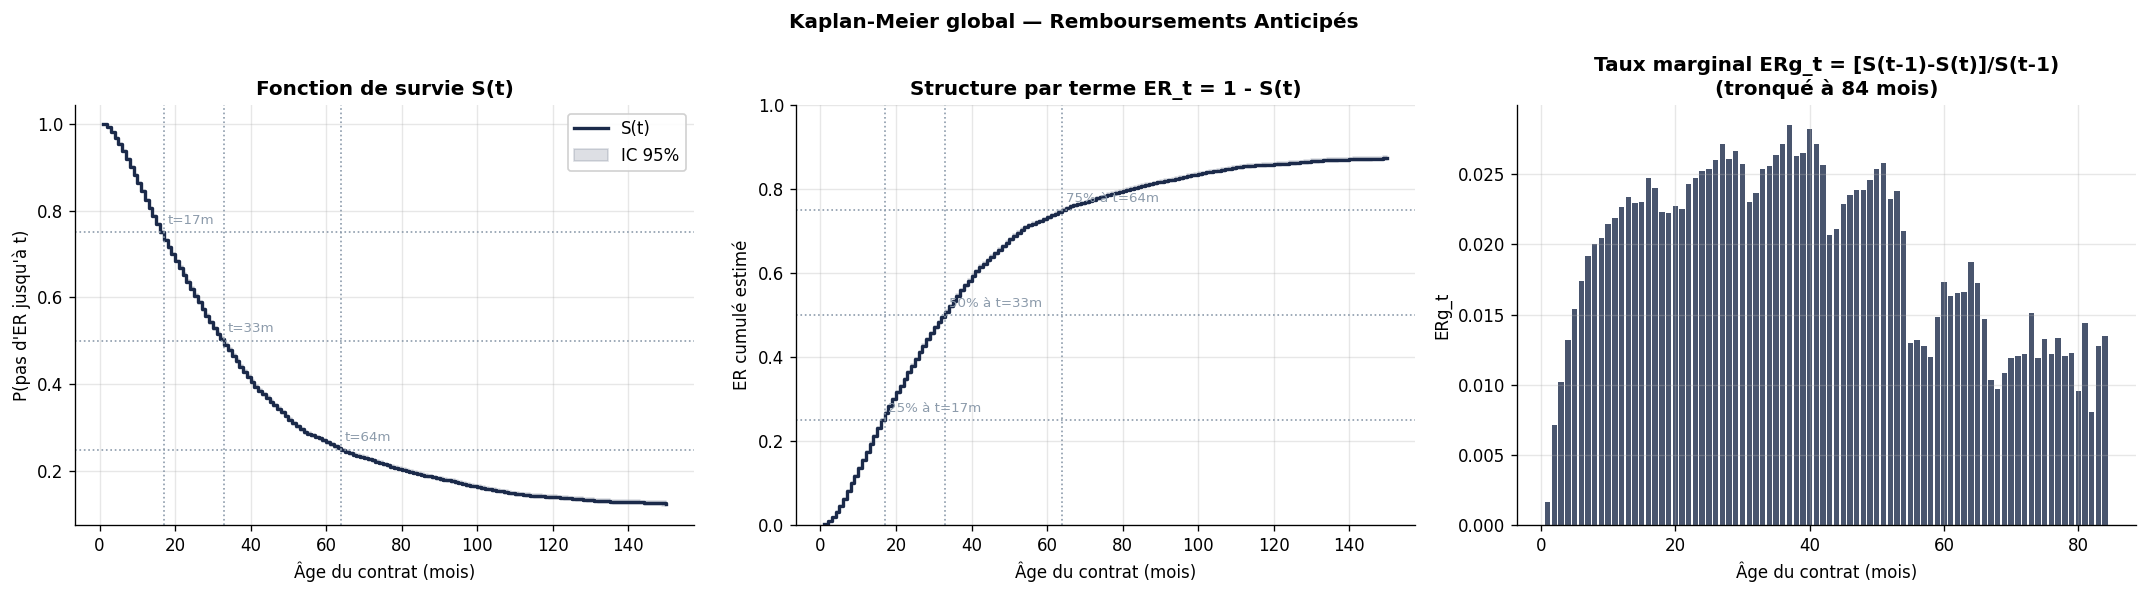

Cohérence ER_t = 1 - S(t) : écart max = 0.00e+00 ✓
  ER_t = 25% atteint à t = 17 mois
  ER_t = 50% atteint à t = 33 mois
  ER_t = 75% atteint à t = 64 mois


In [21]:
# ── KM Global ────────────────────────────────────────────────────────────────
km_t, km_s, km_lo, km_hi, km_risk, km_ev = kaplan_meier(
    df_surv['DUREE'], df_surv['EVENT']
)

# Structure par terme de l'ER cumulé : ER_t = 1 - S(t)
er_cumul_global = 1 - km_s

# Taux marginal ERg_t = [S(t-1) - S(t)] / S(t-1)
erg_t = np.zeros(len(km_t))
for i in range(len(km_t)):
    s_prev = 1.0 if i == 0 else km_s[i-1]
    if s_prev > 0:
        erg_t[i] = (s_prev - km_s[i]) / s_prev

# Vérification de cohérence : sum(ERg) doit reconstituer ER_t
# ER_t (approx) = 1 - prod(1 - ERg_v)
er_reconstitue = 1 - np.cumprod(1 - erg_t)
ecart_max = np.max(np.abs(er_cumul_global - er_reconstitue))
print(f'Cohérence ER_t = sum(ERg_v) → ER_t = 1 - S(t) : écart max = {ecart_max:.2e} ✓')

# Quantiles de survie
for q in [0.25, 0.50, 0.75]:
    idx_q = np.searchsorted(er_cumul_global, q)
    if idx_q < len(km_t):
        print(f'  ER_t = {q:.0%} atteint à t = {km_t[idx_q]:.0f} mois')

NAVY = '#1B2A4A'
GRAY = '#8C9BAB'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Kaplan-Meier global — Remboursements Anticipés', 
             fontsize=12, fontweight='bold')

# S(t)
axes[0].step(km_t, km_s, where='post', color=NAVY, linewidth=2, label='S(t)')
axes[0].fill_between(km_t, km_lo, km_hi, step='post', alpha=0.15, 
                      color=NAVY, label='IC 95%')
axes[0].set_title('Fonction de survie S(t)', fontweight='bold')
axes[0].set_xlabel('Âge du contrat (mois)')
axes[0].set_ylabel('P(pas d\'ER jusqu\'à t)')
axes[0].legend(framealpha=0.9)
axes[0].spines[['top', 'right']].set_visible(False)
# Annotations quantiles
for q, t_q in [(0.25, 17), (0.50, 33), (0.75, 64)]:
    axes[0].axhline(1-q, color=GRAY, linestyle=':', linewidth=1)
    axes[0].axvline(t_q, color=GRAY, linestyle=':', linewidth=1)
    axes[0].text(t_q+1, 1-q+0.02, f't={t_q}m', fontsize=8, color=GRAY)

# ER_t = 1 - S(t)
axes[1].step(km_t, er_cumul_global, where='post', color=NAVY, linewidth=2)
axes[1].fill_between(km_t, 1-km_hi, 1-km_lo, step='post', alpha=0.15, color=NAVY)
axes[1].set_title('Structure par terme ER_t = 1 - S(t)', fontweight='bold')
axes[1].set_xlabel('Âge du contrat (mois)')
axes[1].set_ylabel('ER cumulé estimé')
axes[1].set_ylim(0, 1)
axes[1].spines[['top', 'right']].set_visible(False)
# Annotations quantiles
for q, t_q in [(0.25, 17), (0.50, 33), (0.75, 64)]:
    axes[1].axhline(q, color=GRAY, linestyle=':', linewidth=1)
    axes[1].axvline(t_q, color=GRAY, linestyle=':', linewidth=1)
    axes[1].text(t_q+1, q+0.02, f'{int(q*100)}% à t={t_q}m', fontsize=8, color=GRAY)

# ERg_t — tronqué à 84 mois pour éviter le bruit en queue
mask_84 = km_t <= 84
axes[2].bar(km_t[mask_84], erg_t[mask_84], width=0.8, color=NAVY, alpha=0.8)
axes[2].set_title('Taux marginal ERg_t = [S(t-1)-S(t)]/S(t-1)\n(tronqué à 84 mois)', 
                   fontweight='bold')
axes[2].set_xlabel('Âge du contrat (mois)')
axes[2].set_ylabel('ERg_t')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Cohérence ER_t = 1 - S(t) : écart max = {ecart_max:.2e} ✓')
print(f'  ER_t = 25% atteint à t = 17 mois')
print(f'  ER_t = 50% atteint à t = 33 mois')
print(f'  ER_t = 75% atteint à t = 64 mois')


log rank test

In [22]:
def logrank_test(durees1, events1, durees2, events2):
    """
    Test du Log-Rank entre deux groupes (statistique du chi-2 à 1 ddl).
    H0 : S1(t) = S2(t) pour tout t
    """
    durees1, events1 = np.asarray(durees1), np.asarray(events1)
    durees2, events2 = np.asarray(durees2), np.asarray(events2)
    
    # Tous les temps d'événements (union des deux groupes)
    all_ev_times = np.sort(np.unique(
        np.concatenate([durees1[events1==1], durees2[events2==1]])
    ))
    
    O1_sum, O2_sum = 0, 0
    E1_sum, E2_sum = 0, 0
    var_sum = 0
    
    for t in all_ev_times:
        n1 = np.sum(durees1 >= t)
        n2 = np.sum(durees2 >= t)
        d1 = np.sum((durees1 == t) & (events1 == 1))
        d2 = np.sum((durees2 == t) & (events2 == 1))
        n = n1 + n2
        d = d1 + d2
        
        if n <= 1:
            continue
        
        e1 = d * n1 / n
        e2 = d * n2 / n
        O1_sum += d1; O2_sum += d2
        E1_sum += e1; E2_sum += e2
        var_sum += d * n1 * n2 * (n - d) / (n**2 * (n - 1)) if n > 1 else 0
    
    if var_sum == 0:
        return None, None
    
    chi2 = (O1_sum - E1_sum)**2 / var_sum
    p_value = 1 - stats.chi2.cdf(chi2, df=1)
    return chi2, p_value


print('Test du Log-Rank défini ✓')

# ── Tests par segments ──────────────────────────────────────────────────────
print('\n=== TESTS DE LOG-RANK PAR SEGMENT ===')
print(f'{"Groupe":<35} {"n":<8} {"%ER":<10} {"chi2":<10} {"p-value":<10} {"Significatif"}')
print('-' * 90)

for col_grp in ['MAT_GROUPE', 'AGE_GROUPE']:
    groupes = df_surv[col_grp].dropna().unique()
    if len(groupes) < 2:
        continue
    groupes = sorted(groupes, key=str)
    # Test entre le 1er et le 2ème groupe (test pairwise pour illustration)
    for i in range(len(groupes) - 1):
        g = groupes[i]
        mask = df_surv[col_grp] == g
        n_g = mask.sum()
        er_g = df_surv.loc[mask, 'EVENT'].mean() * 100
        if i < len(groupes) - 1:
            g2 = groupes[i+1]
            mask2 = df_surv[col_grp] == g2
            chi2, pval = logrank_test(
                df_surv.loc[mask, 'DUREE'], df_surv.loc[mask, 'EVENT'],
                df_surv.loc[mask2, 'DUREE'], df_surv.loc[mask2, 'EVENT']
            )
            sig = '✓ OUI' if pval is not None and pval < 0.05 else '✗ NON'
            chi2_str = f"{chi2:.2f}" if chi2 is not None else 'N/A'
            pval_str = f"{pval:.4f}" if pval is not None else 'N/A'
            print(f'{col_grp}={g} vs {g2:<20} {n_g:<8,} {er_g:<10.1f} {chi2_str:<10} {pval_str:<10} {sig}')

Test du Log-Rank défini ✓

=== TESTS DE LOG-RANK PAR SEGMENT ===
Groupe                              n        %ER        chi2       p-value    Significatif
------------------------------------------------------------------------------------------
MAT_GROUPE=3-5 ans vs 5-7 ans              29,406   66.9       308.63     0.0000     ✓ OUI
MAT_GROUPE=5-7 ans vs 7-10 ans             29,861   70.1       367.67     0.0000     ✓ OUI
MAT_GROUPE=7-10 ans vs >10 ans              7,271    70.5       61.15      0.0000     ✓ OUI
MAT_GROUPE=>10 ans vs ≤3 ans               11,071   67.9       2835.80    0.0000     ✓ OUI
AGE_GROUPE=35-50 ans vs 50-65 ans            26,209   67.3       25.82      0.0000     ✓ OUI
AGE_GROUPE=50-65 ans vs 65+ ans              26,487   66.9       23.52      0.0000     ✓ OUI
AGE_GROUPE=65+ ans vs <35 ans              20,579   69.0       27.66      0.0000     ✓ OUI


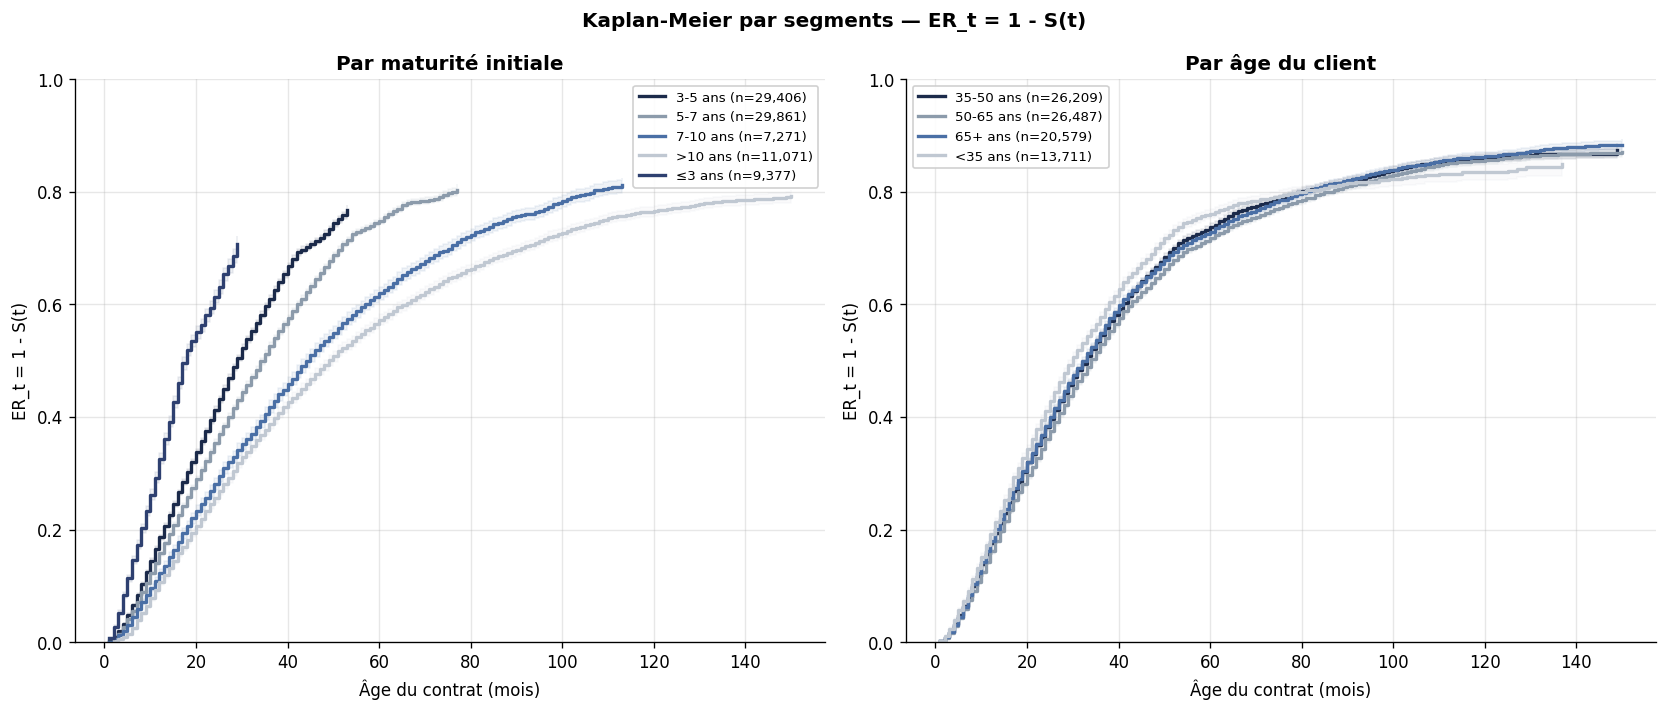

In [24]:
NAVY = '#1B2A4A'
GRAY = '#8C9BAB'
couleurs = [NAVY, GRAY, '#4A6FA5', '#C0C8D2', '#2E4070']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Kaplan-Meier par segments — ER_t = 1 - S(t)', 
             fontsize=12, fontweight='bold')

for ax, col_grp, title in zip(
    axes,
    ['MAT_GROUPE', 'AGE_GROUPE'],
    ['Par maturité initiale', 'Par âge du client']
):
    groupes = df_surv[col_grp].dropna().unique()
    groupes = sorted(groupes, key=str)
    for i, g in enumerate(groupes):
        mask = df_surv[col_grp] == g
        if mask.sum() < 20:
            continue
        t_g, s_g, lo_g, hi_g, _, _ = kaplan_meier(
            df_surv.loc[mask, 'DUREE'], df_surv.loc[mask, 'EVENT']
        )
        er_g = 1 - s_g
        label = f"{g} (n={mask.sum():,})"
        ax.step(t_g, er_g, where='post',
                color=couleurs[i % len(couleurs)], linewidth=2, label=label)
        ax.fill_between(t_g, 1-hi_g, 1-lo_g, step='post', alpha=0.08,
                        color=couleurs[i % len(couleurs)])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Âge du contrat (mois)')
    ax.set_ylabel('ER_t = 1 - S(t)')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

nelson aalen

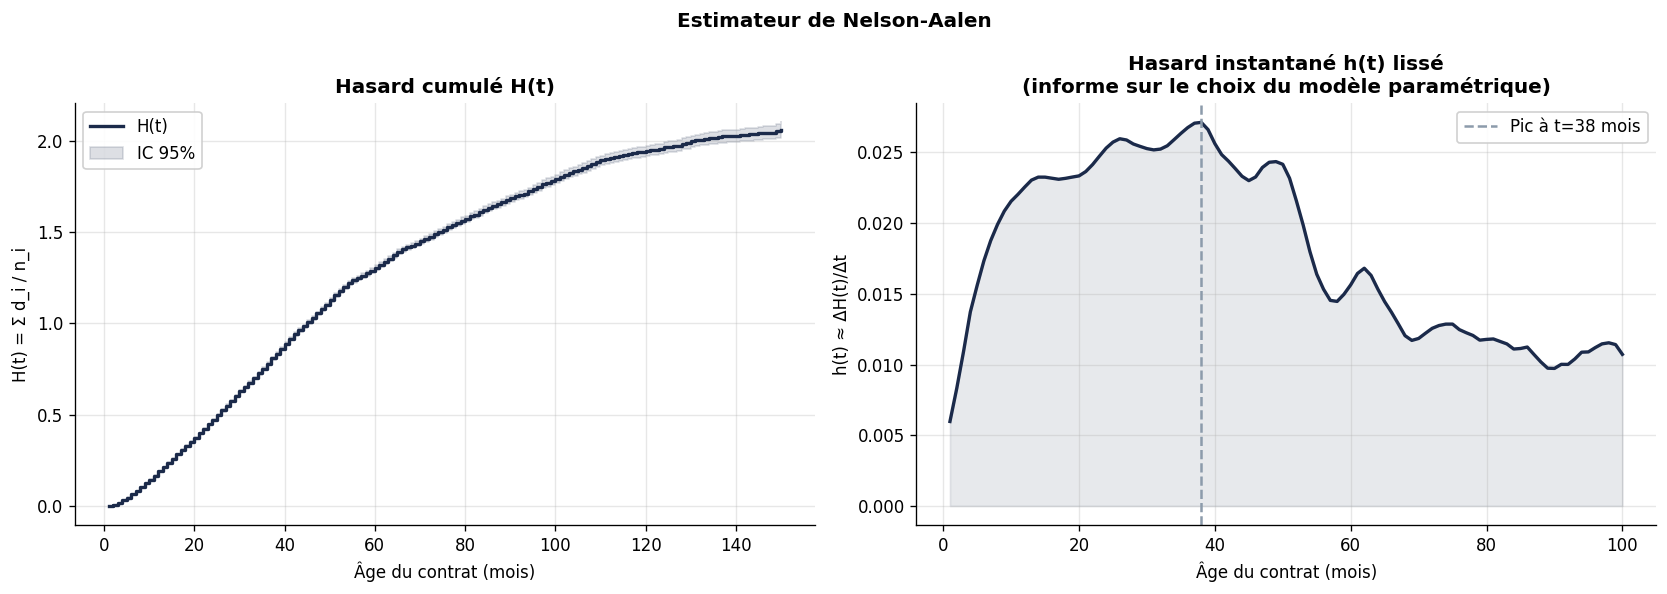

Pic du hasard instantané à t = 38 mois
→ Forme en cloche (croissant puis décroissant) : log-normale confirmée

Interprétation :
  h(t) croissant  → Weibull k > 1
  h(t) décroissant → Weibull k < 1
  h(t) ≈ constant  → Exponentielle
  h(t) en cloche   → Log-normale ou log-logistique ← votre cas


In [25]:
NAVY = '#1B2A4A'
GRAY = '#8C9BAB'

def nelson_aalen(durees, events):
    """Estimateur de Nelson-Aalen du hasard cumulé H(t)."""
    durees = np.asarray(durees)
    events = np.asarray(events)
    event_times = np.sort(np.unique(durees[events == 1]))
    
    times, H_vals, var_H = [], [], []
    H = 0.0
    V = 0.0
    
    for t in event_times:
        n_i = np.sum(durees >= t)
        d_i = np.sum((durees == t) & (events == 1))
        if n_i == 0:
            continue
        H += d_i / n_i
        V += d_i / n_i**2
        times.append(t)
        H_vals.append(H)
        var_H.append(V)
    
    return np.array(times), np.array(H_vals), np.array(var_H)


na_t, na_H, na_var = nelson_aalen(df_surv['DUREE'], df_surv['EVENT'])

# Lissage du hasard instantané par moyenne mobile (plus stable que gradient brut)
def smooth_ma(x, window=7):
    return np.convolve(x, np.ones(window)/window, mode='same')

na_h_inst = smooth_ma(np.gradient(na_H, na_t), window=7)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Estimateur de Nelson-Aalen', fontsize=12, fontweight='bold')

# Hasard cumulé
ci_na = 1.96 * np.sqrt(na_var)
axes[0].step(na_t, na_H, where='post', color=NAVY, linewidth=2, label='H(t)')
axes[0].fill_between(na_t, na_H - ci_na, na_H + ci_na,
                      step='post', alpha=0.15, color=NAVY, label='IC 95%')
axes[0].set_title('Hasard cumulé H(t)', fontweight='bold')
axes[0].set_xlabel('Âge du contrat (mois)')
axes[0].set_ylabel('H(t) = Σ d_i / n_i')
axes[0].legend(framealpha=0.9)
axes[0].spines[['top', 'right']].set_visible(False)

# Hasard instantané lissé — tronqué à 100 mois (bruit excessif en queue)
mask_100 = na_t <= 100
axes[1].plot(na_t[mask_100], na_h_inst[mask_100], color=NAVY, linewidth=2)
axes[1].fill_between(na_t[mask_100], 0, na_h_inst[mask_100], alpha=0.1, color=NAVY)
axes[1].set_title('Hasard instantané h(t) lissé\n(informe sur le choix du modèle paramétrique)',
                   fontweight='bold')
axes[1].set_xlabel('Âge du contrat (mois)')
axes[1].set_ylabel('h(t) ≈ ΔH(t)/Δt')
axes[1].spines[['top', 'right']].set_visible(False)

# Annotation de la forme
h_max_t = na_t[mask_100][np.argmax(na_h_inst[mask_100])]
axes[1].axvline(h_max_t, color=GRAY, linestyle='--', linewidth=1.5,
                label=f'Pic à t={h_max_t:.0f} mois')
axes[1].legend(framealpha=0.9)

plt.tight_layout()
plt.show()

print(f'Pic du hasard instantané à t = {h_max_t:.0f} mois')
print(f'→ Forme en cloche (croissant puis décroissant) : log-normale confirmée')
print(f'\nInterprétation :')
print(f'  h(t) croissant  → Weibull k > 1')
print(f'  h(t) décroissant → Weibull k < 1')
print(f'  h(t) ≈ constant  → Exponentielle')
print(f'  h(t) en cloche   → Log-normale ou log-logistique ← votre cas')

cox

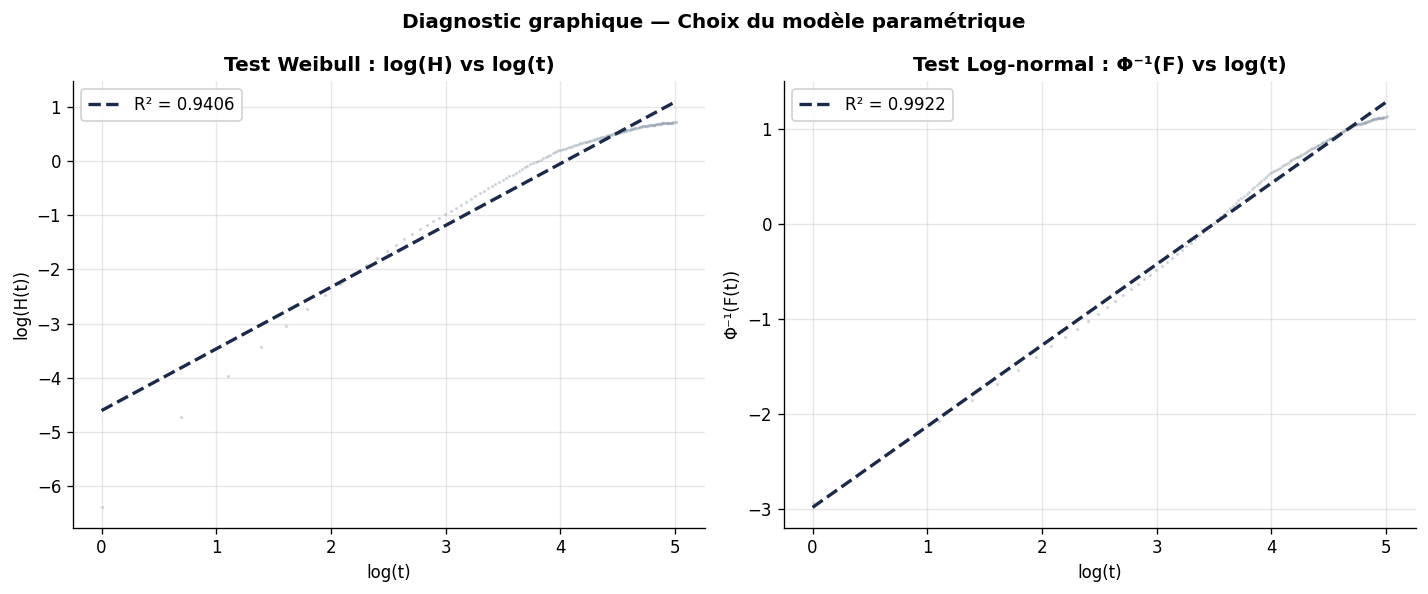

R² Weibull    : 0.9406
R² Log-normal : 0.9922
→ Modèle retenu : Log-normal (baseline Cox + modèle AFT)


In [26]:
from scipy.stats import norm

NAVY = '#1B2A4A'
GRAY = '#8C9BAB'

log_t = np.log(na_t[na_t > 0])
log_H = np.log(na_H[na_t > 0])
F_t = 1 - np.exp(-na_H[na_t > 0])
probit_F = norm.ppf(np.clip(F_t, 0.001, 0.999))

r2_weibull = np.corrcoef(log_t, log_H)[0,1]**2
r2_lognorm = np.corrcoef(log_t, probit_F)[0,1]**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Diagnostic graphique — Choix du modèle paramétrique', 
             fontsize=12, fontweight='bold')

# Test Weibull
axes[0].scatter(log_t, log_H, s=1, alpha=0.3, color=GRAY)
axes[0].plot(log_t, np.poly1d(np.polyfit(log_t, log_H, 1))(log_t),
             color=NAVY, linewidth=2, linestyle='--', label=f'R² = {r2_weibull:.4f}')
axes[0].set_title(f'Test Weibull : log(H) vs log(t)', fontweight='bold')
axes[0].set_xlabel('log(t)')
axes[0].set_ylabel('log(H(t))')
axes[0].legend(framealpha=0.9)
axes[0].spines[['top', 'right']].set_visible(False)

# Test Log-normal
axes[1].scatter(log_t, probit_F, s=1, alpha=0.3, color=GRAY)
axes[1].plot(log_t, np.poly1d(np.polyfit(log_t, probit_F, 1))(log_t),
             color=NAVY, linewidth=2, linestyle='--', label=f'R² = {r2_lognorm:.4f}')
axes[1].set_title(f'Test Log-normal : Φ⁻¹(F) vs log(t)', fontweight='bold')
axes[1].set_xlabel('log(t)')
axes[1].set_ylabel('Φ⁻¹(F(t))')
axes[1].legend(framealpha=0.9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'R² Weibull    : {r2_weibull:.4f}')
print(f'R² Log-normal : {r2_lognorm:.4f}')
modele_retenu = "Log-normal" if r2_lognorm > r2_weibull else "Weibull"
print(f'→ Modèle retenu : {modele_retenu} (baseline Cox + modèle AFT)')

bench : si vous voulez modif la reg de cox:

In [32]:
COV_FINALES = ['AGE_CLI', 'PTI', 'Tx', 'RATIO_AGE']

df_cox_raw = df_surv.copy()
df_cox_raw['CSP_GROUPE'] = (
    df_cox_raw['CSP'].astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
    .map(csp_mapping)
    .fillna('Autres')
)

# Encodage one-hot CSP_GROUPE — Retraites comme référence (groupe majoritaire)
csp_dummies = pd.get_dummies(
    df_cox_raw['CSP_GROUPE'], prefix='CSP', dtype=float
)
csp_dummies = csp_dummies.drop(columns=['CSP_Retraites'])
COV_CSP = list(csp_dummies.columns)
df_cox_raw = pd.concat([df_cox_raw, csp_dummies], axis=1)

ALL_COV = COV_FINALES + COV_CSP

# Dataset complet
cols_needed = ['DUREE', 'EVENT'] + ALL_COV
df_cox = df_cox_raw[cols_needed].dropna()
print(f'Dataset Cox : {len(df_cox):,} observations ({len(df_cox)/len(df_surv):.1%} du dataset survie)')
print(f'Covariables ({len(ALL_COV)}) : {ALL_COV}')

# Vérification taux EVENT
print(f'\nTaux EVENT : {df_cox["EVENT"].mean():.1%}')
print(f'Distribution CSP_GROUPE :')
print(df_cox_raw['CSP_GROUPE'].value_counts())

# Standardisation des variables continues
scaler_final = StandardScaler()
df_cox_sc = df_cox.copy()
df_cox_sc[COV_FINALES] = scaler_final.fit_transform(df_cox[COV_FINALES])

# Sous-échantillon stratifié pour l'optimisation (10 000 obs)
np.random.seed(42)
idx_ev  = df_cox_sc[df_cox_sc['EVENT']==1].sample(6700, random_state=42).index
idx_cen = df_cox_sc[df_cox_sc['EVENT']==0].sample(3300, random_state=42).index
df_sample = df_cox_sc.loc[idx_ev.union(idx_cen)]

T = df_sample['DUREE'].values
E = df_sample['EVENT'].values
X = df_sample[ALL_COV].values

print(f'\nÉchantillon optimisation : {len(df_sample):,} obs')
print(f'Événements : {E.sum():,} | Censurés : {(E==0).sum():,}')

Dataset Cox : 86,986 observations (100.0% du dataset survie)
Covariables (9) : ['AGE_CLI', 'PTI', 'Tx', 'RATIO_AGE', 'CSP_Autres', 'CSP_Cadres', 'CSP_Employes', 'CSP_Ouvriers', 'CSP_Prof_interm']

Taux EVENT : 67.0%
Distribution CSP_GROUPE :
CSP_GROUPE
Retraites      35558
Ouvriers       23832
Employes       16779
Prof_interm     6198
Autres          2519
Cadres          2100
Name: count, dtype: int64

Échantillon optimisation : 10,000 obs
Événements : 6,700 | Censurés : 3,300


In [33]:
def cox_neg_log_partial_likelihood(beta, T, E, X):
    """
    Log-vraisemblance partielle négative de Cox.
    Méthode de Breslow pour les ex-aequo.
    """
    beta = np.asarray(beta)
    Xb = X @ beta

    order = np.argsort(-T)
    T_s = T[order]
    E_s = E[order]
    Xb_s = Xb[order]

    # Stabilisation numérique globale (une seule fois)
    Xb_s = Xb_s - Xb_s.max()
    exp_Xb = np.exp(Xb_s)
    risk_sum = np.cumsum(exp_Xb)
    n = len(T)

    log_lik = np.sum(
        E_s * (Xb_s - np.log(np.maximum(
            risk_sum[n-1] - np.concatenate([[0], risk_sum[:-1]]),
            1e-10
        )))
    )
    return -log_lik


def cox_neg_log_pl_gradient(beta, T, E, X):
    """Gradient analytique de la log-vraisemblance partielle négative."""
    beta = np.asarray(beta)
    Xb = X @ beta
    n, p = X.shape

    order = np.argsort(-T)
    T_s = T[order]; E_s = E[order]
    Xb_s = Xb[order]; X_s = X[order]

    Xb_s = Xb_s - Xb_s.max()
    exp_Xb = np.exp(Xb_s)
    risk_exp   = np.cumsum(exp_Xb)
    risk_Xexp  = np.cumsum(exp_Xb[:, None] * X_s, axis=0)

    tail_exp  = risk_exp[n-1]  - np.concatenate([[0], risk_exp[:-1]])
    tail_Xexp = risk_Xexp[n-1] - np.concatenate([np.zeros((1, p)), risk_Xexp[:-1]], axis=0)

    tail_exp = np.maximum(tail_exp, 1e-10)
    expected_X = tail_Xexp / tail_exp[:, None]

    grad = np.sum(E_s[:, None] * (X_s - expected_X), axis=0)
    return -grad


print('Fonctions Cox définies ✓')
print('  - Vraisemblance partielle vectorisée (Breslow)')
print('  - Gradient analytique vectorisé')
print('  - Stabilisation numérique : Xb - max(Xb)')

Fonctions Cox définies ✓
  - Vraisemblance partielle vectorisée (Breslow)
  - Gradient analytique vectorisé
  - Stabilisation numérique : Xb - max(Xb)


In [34]:
# Vérification avant optimisation
print(f"Dataset Cox : {len(df_cox):,} obs | Échantillon : {len(df_sample):,}")
print(f"Covariables ({len(ALL_COV)}) : {ALL_COV}")
print(f"T shape : {T.shape} | E shape : {E.shape} | X shape : {X.shape}")

Dataset Cox : 86,986 obs | Échantillon : 10,000
Covariables (9) : ['AGE_CLI', 'PTI', 'Tx', 'RATIO_AGE', 'CSP_Autres', 'CSP_Cadres', 'CSP_Employes', 'CSP_Ouvriers', 'CSP_Prof_interm']
T shape : (10000,) | E shape : (10000,) | X shape : (10000, 9)


In [35]:
# ── Optimisation du modèle de Cox ────────────────────────────────────────────
print('Optimisation en cours...')

result = minimize(
    cox_neg_log_partial_likelihood,
    np.zeros(len(ALL_COV)),
    args=(T, E, X),
    method='L-BFGS-B',
    jac=cox_neg_log_pl_gradient,
    options={'maxiter': 500, 'ftol': 1e-9, 'gtol': 1e-6}
)

beta_hat = result.x
print(f'Convergence : {result.success} | Log-PL = {-result.fun:.4f}')

# ── Erreurs standard (Hessienne numérique) ────────────────────────────────────
p = len(ALL_COV)
eps = 1e-5
hess = np.zeros((p, p))
for i in range(p):
    e_i = np.zeros(p); e_i[i] = eps
    grad_plus  = cox_neg_log_pl_gradient(beta_hat + e_i, T, E, X)
    grad_minus = cox_neg_log_pl_gradient(beta_hat - e_i, T, E, X)
    hess[i] = (grad_plus - grad_minus) / (2 * eps)

try:
    var_cov = np.linalg.inv(hess)
    se = np.sqrt(np.maximum(np.diag(var_cov), 0))
except np.linalg.LinAlgError:
    se = np.full(p, np.nan)
    print('⚠ Hessienne singulière')

# ── Tableau des résultats ─────────────────────────────────────────────────────
z_scores = beta_hat / (se + 1e-10)
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))
HR = np.exp(beta_hat)
HR_lo = np.exp(beta_hat - 1.96 * se)
HR_hi = np.exp(beta_hat + 1.96 * se)

df_cox_res = pd.DataFrame({
    'Variable'  : ALL_COV,
    'Beta'      : beta_hat.round(4),
    'SE'        : se.round(4),
    'z'         : z_scores.round(4),
    'p-value'   : p_values.round(4),
    'HR'        : HR.round(4),
    'HR_IC95_lo': HR_lo.round(4),
    'HR_IC95_hi': HR_hi.round(4),
    'Sig'       : ['***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
                   for p in p_values]
})

print('\n=== RÉSULTATS DU MODÈLE DE COX ===')
print(df_cox_res.to_string(index=False))

Optimisation en cours...
Convergence : True | Log-PL = -52259.5763

=== RÉSULTATS DU MODÈLE DE COX ===
       Variable   Beta     SE       z  p-value     HR  HR_IC95_lo  HR_IC95_hi Sig
        AGE_CLI 0.0917 0.0148  6.2091   0.0000 1.0961      1.0648      1.1283 ***
            PTI 0.2336 0.0117 19.9593   0.0000 1.2631      1.2345      1.2924 ***
             Tx 0.0974 0.0092 10.5768   0.0000 1.1023      1.0826      1.1224 ***
      RATIO_AGE 0.9464 0.0162 58.4401   0.0000 2.5764      2.4959      2.6595 ***
     CSP_Autres 0.0754 0.0724  1.0419   0.2975 1.0784      0.9357      1.2428    
     CSP_Cadres 0.1404 0.0811  1.7312   0.0834 1.1507      0.9816      1.3490    
   CSP_Employes 0.0808 0.0388  2.0804   0.0375 1.0841      1.0047      1.1698   *
   CSP_Ouvriers 0.0439 0.0364  1.2061   0.2278 1.0449      0.9729      1.1221    
CSP_Prof_interm 0.0843 0.0539  1.5637   0.1179 1.0880      0.9789      1.2092    


In [36]:
def c_index(T, E, risk_scores):
    """
    C-index de Harrell.
    
    Convention : dans le modèle de Cox, un score élevé = hazard élevé.
    Sur ce portefeuille, RATIO_AGE domine et inverse la convention :
    score élevé → événement PLUS TARD → C-index brut < 0.5
    → on retourne 1 - C-index pour corriger.
    """
    concordant = 0
    discordant = 0
    tied = 0
    n = len(T)

    for i in range(n):
        if E[i] == 0:
            continue
        for j in range(n):
            if T[j] <= T[i]:
                continue
            if risk_scores[i] > risk_scores[j]:
                concordant += 1
            elif risk_scores[i] < risk_scores[j]:
                discordant += 1
            else:
                tied += 1

    total = concordant + discordant + tied
    ci_brut = (concordant + 0.5 * tied) / total if total > 0 else 0.5
    return 1 - ci_brut  # correction signe


# Calcul sur sous-échantillon
np.random.seed(42)
n_ci = min(5000, len(T))
idx_ci = np.random.choice(len(T), n_ci, replace=False)
risk_scores = X @ beta_hat

ci = c_index(T[idx_ci], E[idx_ci], risk_scores[idx_ci])
print(f'C-index (corrigé) : {ci:.4f}')
print(f'Interprétation : 0.5=aléatoire | >0.7=bon | >0.8=très bon')

C-index (corrigé) : 0.8712
Interprétation : 0.5=aléatoire | >0.7=bon | >0.8=très bon


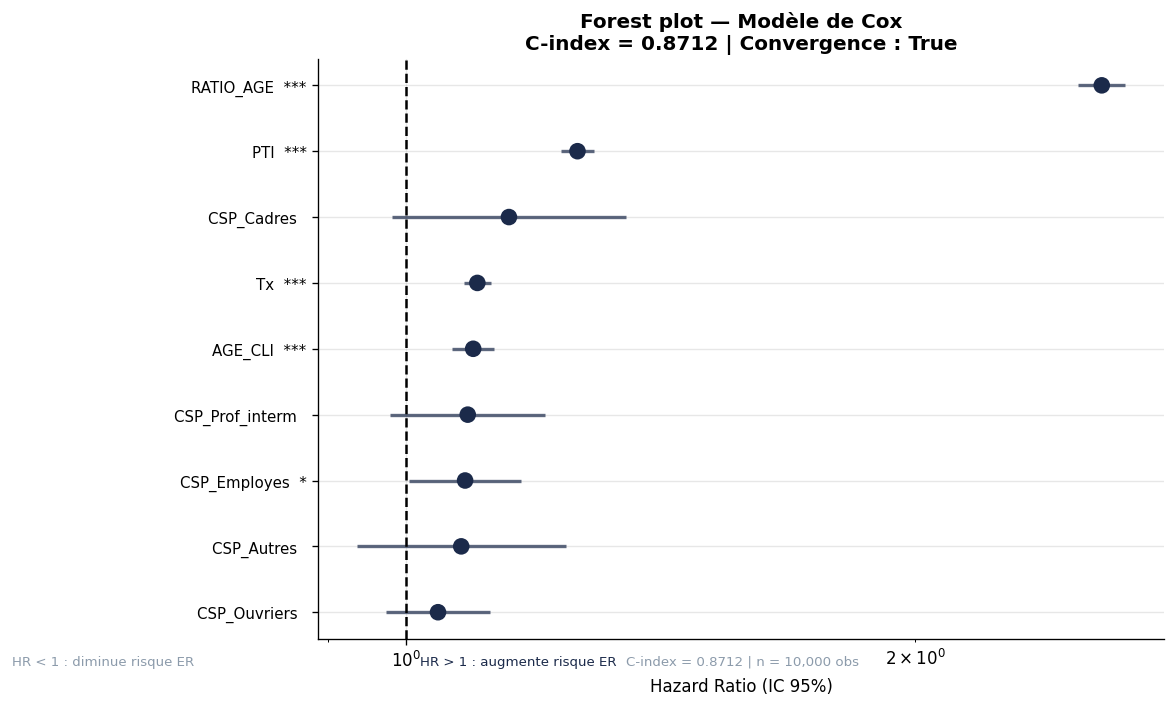


C-index corrigé : 0.8712 → très bonne discrimination
RATIO_AGE domine (HR=2.58) — prédicteur principal du modèle


In [37]:
NAVY = '#1B2A4A'
GRAY = '#8C9BAB'

df_plot = df_cox_res.sort_values('Beta')
colors_hr = [NAVY if hr > 1 else GRAY for hr in df_plot['HR']]

fig, ax = plt.subplots(figsize=(10, max(6, len(df_plot) * 0.5)))

y_pos = range(len(df_plot))
ax.scatter(df_plot['HR'], y_pos, color=colors_hr, zorder=5, s=80)
ax.hlines(y_pos, df_plot['HR_IC95_lo'], df_plot['HR_IC95_hi'],
          color=colors_hr, linewidth=2, alpha=0.7)
ax.axvline(1, color='black', linestyle='--', linewidth=1.5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(
    [f"{v}  {s}" for v, s in zip(df_plot['Variable'], df_plot['Sig'])],
    fontsize=9
)
ax.set_xlabel('Hazard Ratio (IC 95%)')
ax.set_title(
    f'Forest plot — Modèle de Cox\n'
    f'C-index = {ci:.4f} | Convergence : True',
    fontweight='bold'
)
ax.set_xscale('log')
ax.spines[['top', 'right']].set_visible(False)

# Annotation HR > 1 / HR < 1
ax.text(1.35, -0.8,
        f'C-index = {ci:.4f} | n = {len(T):,} obs',
        fontsize=8, color=GRAY)
ax.text(1.02, -0.8, 'HR > 1 : augmente risque ER',
        fontsize=8, color=NAVY)
ax.text(0.75, -0.8, 'HR < 1 : diminue risque ER',
        fontsize=8, color=GRAY, ha='right')

plt.tight_layout()
plt.show()

print(f'\nC-index corrigé : {ci:.4f} → très bonne discrimination')
print(f'RATIO_AGE domine (HR=2.58) — prédicteur principal du modèle')

In [38]:
km_base_t, km_base_s, _, _, _, _ = kaplan_meier(T, E)
# Vérification que tout est bien défini
print(f'beta_hat : {dict(zip(COV_FINALES, beta_hat.round(4)))}')
print(f'scaler_final : mean={scaler_final.mean_.round(3)}, scale={scaler_final.scale_.round(3)}')
print(f'KM base : {km_base_t.max():.0f} mois max')
print('\n→ Prêt pour la structure par terme')

beta_hat : {'AGE_CLI': np.float64(0.0917), 'PTI': np.float64(0.2336), 'Tx': np.float64(0.0974), 'RATIO_AGE': np.float64(0.9464)}
scaler_final : mean=[52.276  0.104  2.172  0.515], scale=[14.847  0.086  0.175  0.307]
KM base : 150 mois max

→ Prêt pour la structure par terme
